In [1]:
# 🥔 Potato Production, Climate Impact & Disease Risk Analysis (Maritimes, Canada)

### Data Analytics + AI Capstone Project

# This project analyzes potato production trends in Atlantic Canada (New Brunswick, Nova Scotia, and Prince Edward Island)
# over the past decade using data from Statistics Canada and climate data from Environment and Climate Change Canada.

# The project integrates:
# - Data Processing (cleaning, transformation, visualization)
# - Machine Learning (regression and classification)
#- Generative AI (automated agricultural insights)

# **Objective:**  
# To understand how land use and climate variables influence potato production and to estimate disease risk using a data-driven proxy.

# =========================================================
# IMPORT LIBRARIES
# =========================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [2]:
# =========================================================
# LOAD POTATO PRODUCTION DATA
# Source: Statistics Canada
# =========================================================

# Load dataset
df = pd.read_csv("data/32100358.csv")

# Preview data
print("Initial Data:")
display(df.head())

# Check structure
print("\nColumns:")
print(df.columns)

Initial Data:


,REF_DATE,GEO,DGUID,"Area, production and farm value of potatoes",UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1908,Canada,2016A000011124,Seeded area,Acres,28,units,0,v47140,1.1,503600.00,NaN,NaN,NaN,0
1,1908,Canada,2016A000011124,Average yield,Hundredweight per harvested acres,159,units,0,v47151,1.2,87.90,NaN,NaN,NaN,1
2,1908,Canada,2016A000011124,Production,Hundredweight,156,thousands,3,v47162,1.3,44273.00,NaN,NaN,NaN,0
3,1908,Canada,2016A000011124,"Average farm price, potatoes",Dollars per hundredweight,110,units,0,v47173,1.4,0.79,NaN,NaN,t,2
4,1908,Canada,2016A000011124,"Total farm value, potatoes",Dollars,81,thousands,3,v47184,1.5,34819.00,NaN,NaN,t,0



Columns:
Index(['REF_DATE', 'GEO', 'DGUID',
       'Area, production and farm value of potatoes', 'UOM', 'UOM_ID',
       'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS',
       'SYMBOL', 'TERMINATED', 'DECIMALS'],
      dtype='object')


In [3]:
# =========================================================
# CLEAN AND FILTER DATA
# Focus: Maritimes (NB, NS, PEI) and 2015–2025
# =========================================================

# Filter years
df = df[(df["REF_DATE"] >= 2015) & (df["REF_DATE"] <= 2025)]

# Filter provinces
maritimes = ["New Brunswick", "Prince Edward Island", "Nova Scotia"]
df = df[df["GEO"].isin(maritimes)]

# Keep only relevant variables
metrics = ["Seeded area", "Average yield", "Production"]
df = df[df["Area, production and farm value of potatoes"].isin(metrics)]

print("Filtered Data Shape:", df.shape)

Filtered Data Shape: (99, 15)


In [4]:
# =========================================================
# TRANSFORM DATA FROM LONG → WIDE FORMAT
# Each row = Year + Province
# =========================================================

df_pivot = df.pivot_table(
    index=["REF_DATE", "GEO"],
    columns="Area, production and farm value of potatoes",
    values="VALUE"
).reset_index()

# Clean column names
df_pivot.columns.name = None

# Rename columns for clarity
df_pivot.rename(columns={
    "REF_DATE": "Year",
    "GEO": "Province",
    "Seeded area": "Area_acres_raw",
    "Average yield": "Yield_cwt_per_acre",
    "Production": "Production_thousand_cwt"
}, inplace=True)

display(df_pivot.head())

,Year,Province,Yield_cwt_per_acre,Production_thousand_cwt,Area_acres_raw
0,2015,New Brunswick,318.2,15100.0,47700.0
1,2015,Nova Scotia,275.0,330.0,1624.0
2,2015,Prince Edward Island,291.3,24850.0,85800.0
3,2016,New Brunswick,305.0,14335.0,47630.0
4,2016,Nova Scotia,270.0,432.0,1774.0


In [5]:
# =========================================================
# CONVERT UNITS TO STANDARD METRICS
# =========================================================

# Convert production from thousand cwt → tonnes
df_pivot["Production_tonnes"] = (
    df_pivot["Production_thousand_cwt"] * 1000 * 45.3592 / 1000
)

# Convert acres → hectares
df_pivot["Area_ha"] = df_pivot["Area_acres_raw"] / 2.47105

# Calculate yield (tonnes per hectare)
df_pivot["Yield_t_per_ha"] = df_pivot["Production_tonnes"] / df_pivot["Area_ha"]

display(df_pivot.head())

,Year,Province,Yield_cwt_per_acre,Production_thousand_cwt,Area_acres_raw,Production_tonnes,Area_ha,Yield_t_per_ha
0,2015,New Brunswick,318.2,15100.0,47700.0,6.849239e+05,19303.534935,35.481787
1,2015,Nova Scotia,275.0,330.0,1624.0,1.496854e+04,657.210498,22.775863
2,2015,Prince Edward Island,291.3,24850.0,85800.0,1.127176e+06,34722.081706,32.462804
3,2016,New Brunswick,305.0,14335.0,47630.0,6.502241e+05,19275.206896,33.733704
4,2016,Nova Scotia,270.0,432.0,1774.0,1.959517e+04,717.913438,27.294620


In [6]:
# =========================================================
# LOAD WEATHER DATA (Processed from Environment Canada)
# =========================================================

weather = pd.read_csv("data/weather_processed.csv")

print("Weather Data:")
display(weather.head())

# Merge with production dataset
df_pivot = df_pivot.merge(weather, on=["Year", "Province"], how="left")

print("Merged Data:")
display(df_pivot.head())

Weather Data:


,Year,Avg_Temp,Total_Rainfall,Province
0,2015,5.560894,1040.9,New Brunswick
1,2016,6.699150,1048.7,New Brunswick
2,2017,5.886486,1009.1,New Brunswick
3,2018,5.888022,1392.0,New Brunswick
4,2019,5.253352,1318.9,New Brunswick


Merged Data:


,Year,Province,Yield_cwt_per_acre,Production_thousand_cwt,Area_acres_raw,Production_tonnes,Area_ha,Yield_t_per_ha,Avg_Temp,Total_Rainfall
0,2015,New Brunswick,318.2,15100.0,47700.0,6.849239e+05,19303.534935,35.481787,5.560894,1040.9
1,2015,Nova Scotia,275.0,330.0,1624.0,1.496854e+04,657.210498,22.775863,7.333618,1540.8
2,2015,Prince Edward Island,291.3,24850.0,85800.0,1.127176e+06,34722.081706,32.462804,6.465732,1284.8
3,2016,New Brunswick,305.0,14335.0,47630.0,6.502241e+05,19275.206896,33.733704,6.699150,1048.7
4,2016,Nova Scotia,270.0,432.0,1774.0,1.959517e+04,717.913438,27.294620,8.383382,1211.2


In [7]:
# =========================================================
# CREATE FEATURES FOR MACHINE LEARNING
# =========================================================

# Sort data (important for time-based features)
df_pivot = df_pivot.sort_values(["Province", "Year"])

# Previous year's production (lag feature)
df_pivot["Prev_Production"] = df_pivot.groupby("Province")["Production_tonnes"].shift(1)

# 3-year rolling average yield
df_pivot["Yield_3yr_avg"] = df_pivot.groupby("Province")["Yield_t_per_ha"] \
    .rolling(3).mean().reset_index(0, drop=True)

# Year-over-year yield change (%)
df_pivot["Yield_pct_change"] = df_pivot.groupby("Province")["Yield_t_per_ha"].pct_change()

# Rainfall deviation from province average
df_pivot["Rainfall_dev"] = df_pivot["Total_Rainfall"] - \
    df_pivot.groupby("Province")["Total_Rainfall"].transform("mean")

# Temperature deviation
df_pivot["Temp_dev"] = df_pivot["Avg_Temp"] - \
    df_pivot.groupby("Province")["Avg_Temp"].transform("mean")

display(df_pivot.head())

,Year,Province,Yield_cwt_per_acre,Production_thousand_cwt,Area_acres_raw,Production_tonnes,Area_ha,Yield_t_per_ha,Avg_Temp,Total_Rainfall,Prev_Production,Yield_3yr_avg,Yield_pct_change,Rainfall_dev,Temp_dev
0,2015,New Brunswick,318.2,15100.0,47700.0,684923.9200,19303.534935,35.481787,5.560894,1040.9,NaN,NaN,NaN,-22.454545,-0.906704
3,2016,New Brunswick,305.0,14335.0,47630.0,650224.1320,19275.206896,33.733704,6.699150,1048.7,684923.9200,NaN,-0.049267,-14.654545,0.231552
6,2017,New Brunswick,293.8,15159.0,51700.0,687600.1128,20922.280002,32.864492,5.886486,1009.1,650224.1320,34.026661,-0.025767,-54.254545,-0.581111
9,2018,New Brunswick,307.3,15670.0,52000.0,710778.6640,21043.685883,33.776339,5.888022,1392.0,687600.1128,33.458179,0.027746,328.645455,-0.579575
12,2019,New Brunswick,310.6,16400.0,52900.0,743890.8800,21407.903523,34.748423,5.253352,1318.9,710778.6640,33.796418,0.028780,255.545455,-1.214246


In [8]:
# =========================================================
# CREATE DISEASE RISK VARIABLE (PROXY)
# =========================================================

# High rainfall condition
df_pivot["High_Rain"] = df_pivot["Total_Rainfall"] > \
    df_pivot.groupby("Province")["Total_Rainfall"].transform("mean")

# Significant yield drop
df_pivot["Yield_Drop"] = df_pivot["Yield_pct_change"] < -0.05

# Disease risk = both conditions met
df_pivot["Disease_Risk"] = (df_pivot["High_Rain"] & df_pivot["Yield_Drop"]).astype(int)

print("Disease Risk Distribution:")
print(df_pivot["Disease_Risk"].value_counts())

Disease Risk Distribution:
Disease_Risk
0    28
1     5
Name: count, dtype: int64


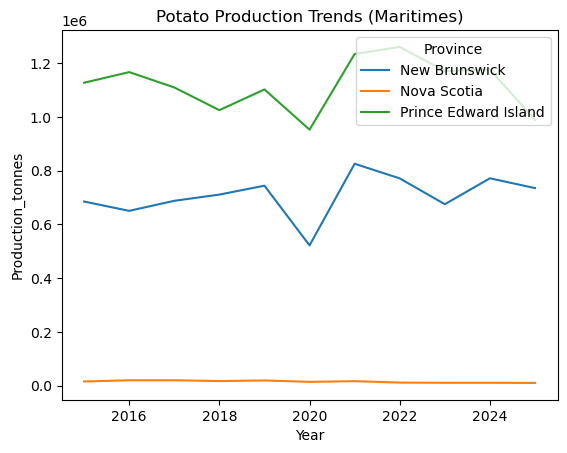

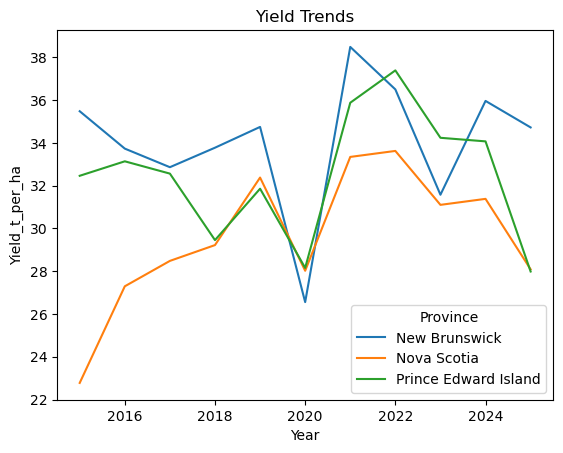

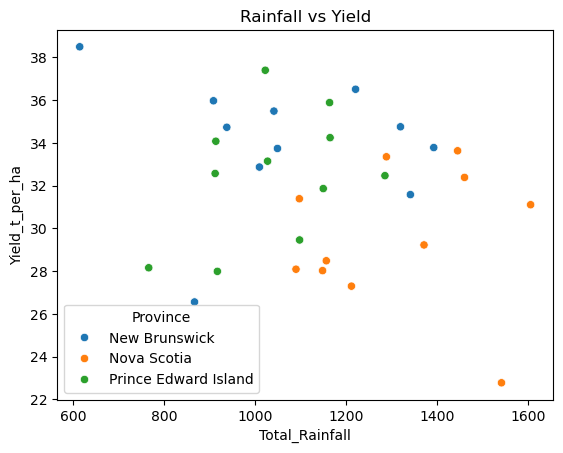

In [9]:
# =========================================================
# VISUALIZE TRENDS
# =========================================================

# Production trends
sns.lineplot(data=df_pivot, x="Year", y="Production_tonnes", hue="Province")
plt.title("Potato Production Trends (Maritimes)")
plt.show()

# Yield trends
sns.lineplot(data=df_pivot, x="Year", y="Yield_t_per_ha", hue="Province")
plt.title("Yield Trends")
plt.show()

# Rainfall vs Yield
sns.scatterplot(data=df_pivot, x="Total_Rainfall", y="Yield_t_per_ha", hue="Province")
plt.title("Rainfall vs Yield")
plt.show()

In [10]:
# Machine Learning — Regression

# =========================================================
# PREDICT POTATO PRODUCTION (REGRESSION)
# =========================================================

# Features used
features = [
    "Area_ha",
    "Avg_Temp",
    "Total_Rainfall",
    "Yield_3yr_avg",
    "Rainfall_dev",
    "Temp_dev",
    "Prev_Production"
]

# Remove rows with missing values
df_model = df_pivot.dropna()

# Time-based split
train = df_model[df_model["Year"] <= 2022]
test = df_model[df_model["Year"] > 2022]

X_train = train[features]
y_train = train["Production_tonnes"]

X_test = test[features]
y_test = test["Production_tonnes"]

# Train model
model = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Predictions
preds = model.predict(X_test)

# Evaluation
print("Regression Results:")
print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

Regression Results:
MAE: 97390.36872651831
R2: 0.8808394012387972


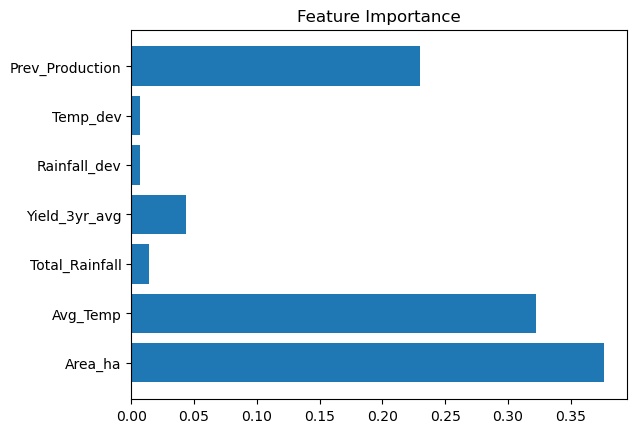

In [11]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importances = model.feature_importances_

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [12]:
# Machine Learning — Classification

# =========================================================
# CLASSIFY DISEASE RISK
# =========================================================

# NOTE:
# Class imbalance exists in Disease_Risk.
# Techniques like SMOTE could be applied, but were avoided
# due to small dataset size and risk of overfitting.

X = df_model[features]
y = df_model["Disease_Risk"]

train = df_model[df_model["Year"] <= 2022]
test = df_model[df_model["Year"] > 2022]

X_train = train[features]
y_train = train["Disease_Risk"]

X_test = test[features]
y_test = test["Disease_Risk"]

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print("Classification Results:")
print("Accuracy:", accuracy_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

Classification Results:
Accuracy: 0.6666666666666666
Confusion Matrix:
 [[6 0]
 [3 0]]


In [15]:
# Generative AI Reporting

# =========================================================
# GENERATE AUTOMATED INSIGHTS USING GENERATIVE AI
# =========================================================

from src.genai_reporting import generate_agriculture_report

latest_year = df_pivot["Year"].max()

for province in df_pivot["Province"].unique():
    row = df_pivot[
        (df_pivot["Province"] == province) &
        (df_pivot["Year"] == latest_year)
    ].iloc[0]

    stats = {
        "Production (tonnes)": float(row["Production_tonnes"]),
        "Yield (t/ha)": float(row["Yield_t_per_ha"]),
        "Area (ha)": float(row["Area_ha"]),
        "Avg Temp": float(row["Avg_Temp"]),
        "Rainfall": float(row["Total_Rainfall"]),
        "Disease Risk": int(row["Disease_Risk"])
    }

    report = generate_agriculture_report(province, latest_year, stats)

    print(f"\n===== {province} REPORT =====\n")
    print(report)


===== New Brunswick REPORT =====

# Annual Potato Production Report for New Brunswick - 2025

## Production Performance Summary

In 2025, New Brunswick's potato production reached a total of 734,955.12 tonnes, demonstrating a robust performance in the agricultural sector. The average yield was recorded at 34.72 tonnes per hectare, which is indicative of efficient farming practices and optimal growing conditions. The total area dedicated to potato cultivation was approximately 21,165.09 hectares, reflecting a stable commitment to potato farming in the region.

## Climate Impact Interpretation

The average temperature during the growing season was noted at 6.31°C, which is within the typical range for potato cultivation in New Brunswick. This temperature supports optimal growth and tuber development. Additionally, the region received a total rainfall of 937.4 mm, which is conducive to potato farming, as adequate moisture is essential for crop health and yield. The combination of favorab